# Comparaison des 3 stratégies Few-shot (Prompt 1)

Compare les **3 stratégies** de sélection d'exemples few-shot : **Fewshot** (type+section), **Fewshot_Kate** (1E+1C sémantique RoBERTa), **Fewshot_Cosine** (1E+1C similarité cosine). Objectif : comparer les performances, voir s'ils se trompent aux mêmes endroits, et déterminer quelle stratégie garder.


## 1. Configuration et chemins


In [94]:
from pathlib import Path
import os

NLI4CT_ROOT = Path(".").resolve()
if not (NLI4CT_ROOT / "results").exists():
    NLI4CT_ROOT = NLI4CT_ROOT / "NLI4CT"
if not (NLI4CT_ROOT / "results").exists():
    raise FileNotFoundError("Dossier results/ introuvable. Lancer le notebook depuis NLI4CT/ ou depuis la racine du dépôt.")

RESULTS_FEWSHOT = NLI4CT_ROOT / "results" / "Fewshot"
RESULTS_KATE = NLI4CT_ROOT / "results" / "Fewshot_Kate"
RESULTS_COSINE = NLI4CT_ROOT / "results" / "Fewshot_Cosine"
FIGURES_DIR = RESULTS_FEWSHOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

GOLD_TEST_JSON = NLI4CT_ROOT / "Gold_test.json"
GOLD_TEST_JSONL = RESULTS_FEWSHOT / "Gold_test_fewshot_prompt1.jsonl"

CSV_FEWSHOT = next(RESULTS_FEWSHOT.glob("pred_fewshot_*.csv"), None)
CSV_KATE = next(RESULTS_KATE.glob("pred_*.csv"), None)
CSV_COSINE = next(RESULTS_COSINE.glob("pred_*.csv"), None)

print("NLI4CT_ROOT (répertoire de base) :", NLI4CT_ROOT)
print("Dossiers existants : Fewshot =", RESULTS_FEWSHOT.exists(), "| Fewshot_Kate =", RESULTS_KATE.exists(), "| Fewshot_Cosine =", RESULTS_COSINE.exists())
print("CSV trouvés :")
print("  Fewshot   :", CSV_FEWSHOT)
print("  Fewshot_Kate :", CSV_KATE)
print("  Fewshot_Cosine:", CSV_COSINE)
n_ok = sum([CSV_FEWSHOT is not None, CSV_KATE is not None, CSV_COSINE is not None])
if n_ok < 2:
    print("\n⚠️  Moins de 2 CSV trouvés : exécuter le notebook depuis le dossier NLI4CT/ (ou la racine du dépôt) et vérifier que les fichiers pred_*.csv sont bien dans results/Fewshot, results/Fewshot_Kate, results/Fewshot_Cosine.")
print("Gold test JSON:", GOLD_TEST_JSON.exists())


NLI4CT_ROOT (répertoire de base) : /Users/lubin/Documents/NLI_Finetuning/NLI4CT
Dossiers existants : Fewshot = True | Fewshot_Kate = True | Fewshot_Cosine = True
CSV trouvés :
  Fewshot   : /Users/lubin/Documents/NLI_Finetuning/NLI4CT/results/Fewshot/pred_fewshot_qwen7b_NLI4CT_prompt1.csv
  Fewshot_Kate : /Users/lubin/Documents/NLI_Finetuning/NLI4CT/results/Fewshot_Kate/pred_fewshot_KATE_qwen7b_NLI4CT_prompt1.csv
  Fewshot_Cosine: /Users/lubin/Documents/NLI_Finetuning/NLI4CT/results/Fewshot_Cosine/pred_fewshot_Cosine_qwen7b_NLI4CT_prompt1.csv
Gold test JSON: True


In [95]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10


## 2. Chargement des données


## 3b. Accord et désaccord entre les 3 stratégies

On regarde où les stratégies sont d'accord (toutes correctes, toutes en erreur) et où elles divergent. **Se trompent-elles aux mêmes endroits ?**

In [96]:
# Colonnes is_correct_* disponibles
acc_cols = [c for c in df_merged.columns if c.startswith('is_correct_')]
if len(acc_cols) < 2:
    print("Moins de 2 stratégies chargées, pas de comparaison d'accord.")
    print("Stratégies présentes dans df_merged :", acc_cols if acc_cols else "aucune (is_correct_*)")
    print("→ Re-exécuter la section 1 (Configuration) puis la section 2 (Chargement) en lançant le notebook depuis le dossier NLI4CT/.")
    print("→ Vérifier que les 3 CSV existent : results/Fewshot/pred_fewshot_*.csv, results/Fewshot_Kate/pred_*.csv, results/Fewshot_Cosine/pred_*.csv")
else:
    # Nombre de stratégies correctes par ligne (0, 1, 2 ou 3)
    df_merged['n_correct'] = df_merged[acc_cols].sum(axis=1)
    n_strat = len(acc_cols)
    print("Répartition du nombre de stratégies correctes (par instance) :")
    print(df_merged['n_correct'].value_counts().sort_index())
    print()
    # Toutes correctes / toutes fausses / partiel
    all_ok = (df_merged['n_correct'] == n_strat).sum()
    all_ko = (df_merged['n_correct'] == 0).sum()
    partiel = len(df_merged) - all_ok - all_ko
    print(f"Toutes correctes ({n_strat}/{n_strat}) : {all_ok} | Toutes en erreur (0/{n_strat}) : {all_ko} | Divergent : {partiel}")
    print()
    # Intersection des erreurs : indices où chaque stratégie se trompe
    err_sets = {c.replace('is_correct_', ''): set(df_merged.loc[~df_merged[c], 'index'].tolist()) for c in acc_cols}
    print("Erreurs par stratégie (nombre) :", {k: len(v) for k, v in err_sets.items()})
    if len(err_sets) >= 2:
        inter = set.intersection(*err_sets.values())
        print(f"Erreurs communes à toutes les stratégies : {len(inter)} exemples (indices: {sorted(inter)[:20]}{'...' if len(inter) > 20 else ''})")
    # Matrice d'accord deux à deux (sur les erreurs)
    from itertools import combinations
    for a, b in combinations(list(err_sets.keys()), 2):
        inter_ab = len(err_sets[a] & err_sets[b])
        print(f"  Erreurs communes {a} / {b} : {inter_ab}")

Répartition du nombre de stratégies correctes (par instance) :
n_correct
0     88
1     45
2     74
3    293
Name: count, dtype: int64

Toutes correctes (3/3) : 293 | Toutes en erreur (0/3) : 88 | Divergent : 119

Erreurs par stratégie (nombre) : {'Fewshot': 140, 'Kate': 143, 'Cosine': 145}
Erreurs communes à toutes les stratégies : 88 exemples (indices: [56, 65, 68, 73, 76, 82, 84, 90, 101, 115, 117, 123, 124, 125, 127, 128, 141, 142, 144, 150]...)
  Erreurs communes Fewshot / Kate : 97
  Erreurs communes Fewshot / Cosine : 100
  Erreurs communes Kate / Cosine : 112


,Situation,Effectif,%
0,Accord : toutes correctes (3/3),293,58.6
1,Accord : toutes en erreur (0/3),88,17.6
2,Désaccord : 1 ou 2 stratégies correctes,119,23.8


Détail par nombre de stratégies correctes (par instance) :


,Effectif,%
Nombre de stratégies correctes,,
0,88,17.6
1,45,9.0
2,74,14.8
3,293,58.6


/var/folders/71/b1s1b9y50596_3t1fgw_1dzw0000gn/T/ipykernel_18390/340260030.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cats, rotation=15, ha='right')


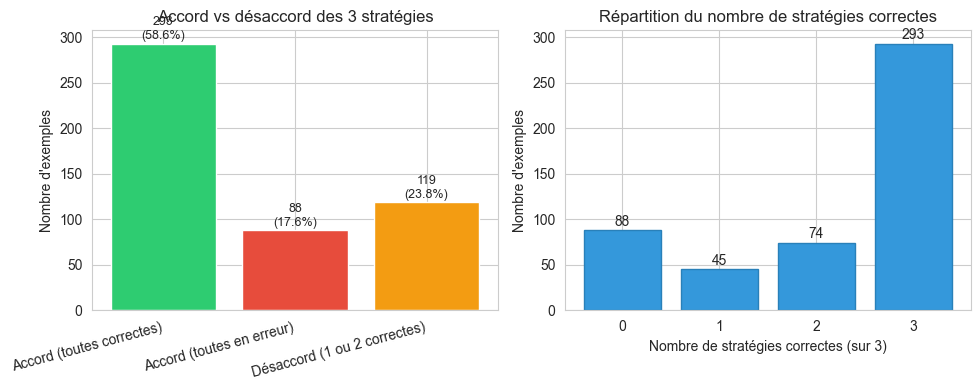

In [97]:
# Tableau et graphique : accord vs désaccord des 3 stratégies
acc_cols = [c for c in df_merged.columns if c.startswith('is_correct_')]
if len(acc_cols) < 2:
    print("Exécuter d'abord la cellule ci-dessus (3b) pour charger n_correct et les stratégies.")
else:
    df_merged['n_correct'] = df_merged[acc_cols].sum(axis=1)
    n_strat = len(acc_cols)
    n_total = len(df_merged)
    all_ok = (df_merged['n_correct'] == n_strat).sum()
    all_ko = (df_merged['n_correct'] == 0).sum()
    partiel = n_total - all_ok - all_ko
    # Tableau récapitulatif
    recap = pd.DataFrame({
        'Situation': [
            f'Accord : toutes correctes ({n_strat}/{n_strat})',
            f'Accord : toutes en erreur (0/{n_strat})',
            'Désaccord : 1 ou 2 stratégies correctes'
        ],
        'Effectif': [all_ok, all_ko, partiel],
        '%': [all_ok/n_total*100, all_ko/n_total*100, partiel/n_total*100]
    })
    display(recap)
    # Détail par nombre de stratégies correctes (0, 1, 2, 3)
    detail = df_merged['n_correct'].value_counts().sort_index()
    detail_pct = (detail / n_total * 100).round(1)
    detail_df = pd.DataFrame({'Effectif': detail, '%': detail_pct})
    detail_df.index.name = 'Nombre de stratégies correctes'
    print("Détail par nombre de stratégies correctes (par instance) :")
    display(detail_df)
    # Graphique en barres
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    # Gauche : accord / désaccord (3 catégories)
    ax = axes[0]
    cats = ['Accord (toutes correctes)', 'Accord (toutes en erreur)', 'Désaccord (1 ou 2 correctes)']
    vals = [all_ok, all_ko, partiel]
    colors_cat = ['#2ecc71', '#e74c3c', '#f39c12']
    bars = ax.bar(cats, vals, color=colors_cat)
    ax.set_xticklabels(cats, rotation=15, ha='right')
    ax.set_ylabel('Nombre d\'exemples')
    ax.set_title('Accord vs désaccord des 3 stratégies')
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 5, f'{v}\n({v/n_total*100:.1f}%)', ha='center', fontsize=9)
    # Droite : détail 0, 1, 2, 3 correctes
    ax = axes[1]
    x = detail.index.astype(int)
    ax.bar(x, detail.values, color='#3498db', edgecolor='#2980b9')
    ax.set_xticks(x)
    ax.set_xlabel('Nombre de stratégies correctes (sur 3)')
    ax.set_ylabel('Nombre d\'exemples')
    ax.set_title('Répartition du nombre de stratégies correctes')
    for i, (xi, v) in enumerate(zip(x, detail.values)):
        ax.text(xi, v + 5, f'{v}', ha='center', fontsize=10)
    plt.tight_layout()
    plt.show()


## 3c. Synthèse : quelle stratégie few-shot garder ?

Résumé pour décider : meilleure accuracy, robustesse (moins d'erreurs uniquement sur cette stratégie), et recouvrement des erreurs.

In [98]:
acc_cols = [c for c in df_merged.columns if c.startswith('is_correct_')]
names = [c.replace('is_correct_', '') for c in acc_cols]
if not acc_cols:
    print("Aucune colonne is_correct_* trouvée. Vérifier que les CSV Fewshot/Kate/Cosine ont bien été chargés (section 2).")
else:
    accs = [df_merged[c].mean() for c in acc_cols]
    best_idx = np.argmax(accs)
    best_name = names[best_idx]
    print("Résumé comparaison des 3 stratégies few-shot (Prompt 1)")
    print("=" * 55)
    for i, n in enumerate(names):
        acc = accs[i]
        mark = " ← MEILLEURE" if i == best_idx else ""
        print(f"  {n:12s} : Accuracy {acc:.2%}{mark}")
    print()
    print(f"Recommandation : stratégie **{best_name}** (accuracy la plus élevée).")
    print("Vérifier aussi les sections 4–6 (performance par type/section/longueur) et")
    print("l'intersection des erreurs ci-dessus : si une stratégie a peu d'erreurs en commun avec les autres, elle peut être plus robuste.")

Résumé comparaison des 3 stratégies few-shot (Prompt 1)
  Fewshot      : Accuracy 72.00% ← MEILLEURE
  Kate         : Accuracy 71.40%
  Cosine       : Accuracy 71.00%

Recommandation : stratégie **Fewshot** (accuracy la plus élevée).
Vérifier aussi les sections 4–6 (performance par type/section/longueur) et
l'intersection des erreurs ci-dessus : si une stratégie a peu d'erreurs en commun avec les autres, elle peut être plus robuste.


In [99]:
def extract_premise_hypothesis_from_user_content(text):
    """Extrait premise et hypothesis (statement) depuis le contenu user du JSONL."""
    if "HYPOTHESIS:" not in text:
        return text[:800] if len(text) > 800 else text, text[:500] if len(text) > 500 else text
    before_hyp, after_hyp = text.split("HYPOTHESIS:", 1)
    premise = before_hyp.replace("PREMISE:", "").strip()
    for sep in (".\n\nAnswer", "?\n\nAnswer", "? Answer", "\n\nAnswer"):
        if sep in after_hyp:
            after_hyp = after_hyp.split(sep)[0]
    statement = after_hyp.strip()
    return premise, statement

def _norm_bool(s):
    return s.apply(lambda x: str(x).strip().lower() == 'true') if s.dtype == object else s.astype(bool)

dfs = {}
if CSV_FEWSHOT:
    dfs['Fewshot'] = pd.read_csv(CSV_FEWSHOT)
    dfs['Fewshot']['is_correct'] = _norm_bool(dfs['Fewshot']['is_correct'])
if CSV_KATE:
    dfs['Kate'] = pd.read_csv(CSV_KATE)
    dfs['Kate']['is_correct'] = _norm_bool(dfs['Kate']['is_correct'])
if CSV_COSINE:
    dfs['Cosine'] = pd.read_csv(CSV_COSINE)
    dfs['Cosine']['is_correct'] = _norm_bool(dfs['Cosine']['is_correct'])

assert dfs, "Aucun CSV trouvé (Fewshot, Kate ou Cosine)."

metadata_list = []
with open(GOLD_TEST_JSONL, 'r', encoding='utf-8') as f:
    for idx, line in enumerate(f):
        if not line.strip():
            continue
        obj = json.loads(line)
        msgs = obj.get("messages", [])
        if len(msgs) < 2:
            continue
        # Few-shot : plusieurs user/assistant ; on prend le DERNIER user (question de test) et le dernier assistant (gold)
        user_content = ""
        label = ""
        for m in msgs:
            if m.get("role") == "user":
                user_content = m.get("content", "")
            elif m.get("role") == "assistant":
                label = m.get("content", "").strip()
        premise, statement = extract_premise_hypothesis_from_user_content(user_content)
        metadata_list.append({'index': idx, 'type': 'N/A', 'section_id': 'N/A', 'premise_jsonl': premise, 'statement': statement, 'label': label})

if GOLD_TEST_JSON.exists():
    with open(GOLD_TEST_JSON, 'r', encoding='utf-8') as f:
        gold_data = json.load(f)
    keys = list(gold_data.keys())
    if len(keys) == len(metadata_list):
        for i in range(len(metadata_list)):
            e = gold_data[keys[i]]
            metadata_list[i]['type'] = e.get('Type', 'N/A')
            metadata_list[i]['section_id'] = e.get('Section_id', 'N/A')

df_metadata = pd.DataFrame(metadata_list)

# Base = premier CSV dispo (Fewshot en priorité)
base_name = 'Fewshot' if 'Fewshot' in dfs else list(dfs.keys())[0]
df_merged = dfs[base_name][['index', 'true_label']].merge(df_metadata, on='index', how='left')
df_merged['premise'] = df_merged['premise_jsonl'].astype(str)
df_merged['hypothesis'] = df_merged['statement'].astype(str)
for name, d in dfs.items():
    pred_col = f'pred_{name}'
    correct_col = f'is_correct_{name}'
    df_merged = df_merged.merge(d[['index', 'predicted_label', 'is_correct']].rename(columns={'predicted_label': pred_col, 'is_correct': correct_col}), on='index', how='left')

# Compatibilité avec les sections suivantes : is_correct / predicted_label = première stratégie
acc_cols = [c for c in df_merged.columns if c.startswith('is_correct_')]
if acc_cols:
    df_merged['is_correct'] = df_merged[acc_cols[0]]
    first_name = acc_cols[0].replace('is_correct_', '')
    df_merged['predicted_label'] = df_merged.get(f'pred_{first_name}', df_merged['true_label'])

def safe_len(s):
    return len(str(s)) if pd.notna(s) else 0
df_merged['premise_len'] = df_merged['premise'].apply(safe_len)
df_merged['hypothesis_len'] = df_merged['hypothesis'].apply(safe_len)
df_merged['prompt_len'] = df_merged['premise_len'] + df_merged['hypothesis_len']

def safe_length_bin(series):
    q = series.quantile([0, 1/3, 2/3, 1])
    edges = np.sort(q.unique())
    n_bins = max(1, len(edges) - 1)
    if n_bins == 1:
        return pd.Series('Moyen', index=series.index)
    labels = ['Court', 'Moyen', 'Long'][:n_bins]
    return pd.cut(series, bins=edges, labels=labels, include_lowest=True)
df_merged['length_bin'] = safe_length_bin(df_merged['prompt_len'])

print("Exemples :", len(df_merged))
print("Stratégies chargées :", [k for k in dfs])
print("Métadonnées (type, section) :", df_metadata['type'].notna().all() and (df_metadata['section_id'] != 'N/A').all())


Exemples : 500
Stratégies chargées : ['Fewshot', 'Kate', 'Cosine']
Métadonnées (type, section) : True


## 3. Statistiques globales


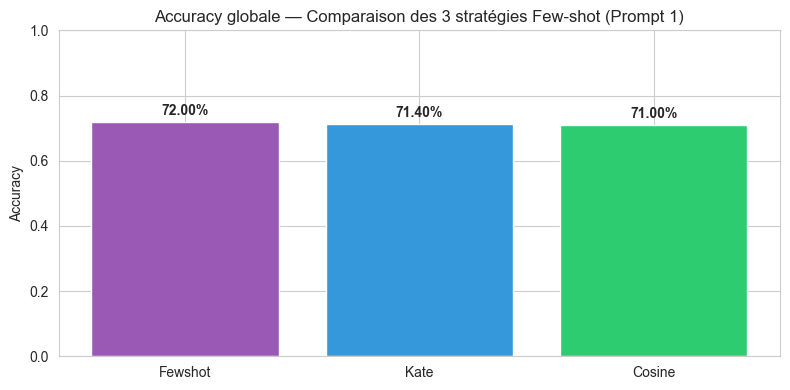

,Accuracy
Fewshot,0.720
Kate,0.714
Cosine,0.710


In [100]:
acc_cols = [c for c in df_merged.columns if c.startswith('is_correct_')]
accuracies = {c.replace('is_correct_', ''): df_merged[c].mean() for c in acc_cols}
names = list(accuracies.keys())
accs = list(accuracies.values())
colors = ['#9b59b6', '#3498db', '#2ecc71'][:len(names)]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(names, accs, color=colors)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.set_title('Accuracy globale — Comparaison des 3 stratégies Few-shot (Prompt 1)')
for bar, a in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, a + 0.02, f'{a:.2%}', ha='center', fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES_DIR / '01_accuracy_comparison_3strategies.png', dpi=150, bbox_inches='tight')
plt.show()
pd.DataFrame([accuracies]).T.rename(columns={0: 'Accuracy'})


## 4. Analyse par type de tâche (Single vs Comparison)


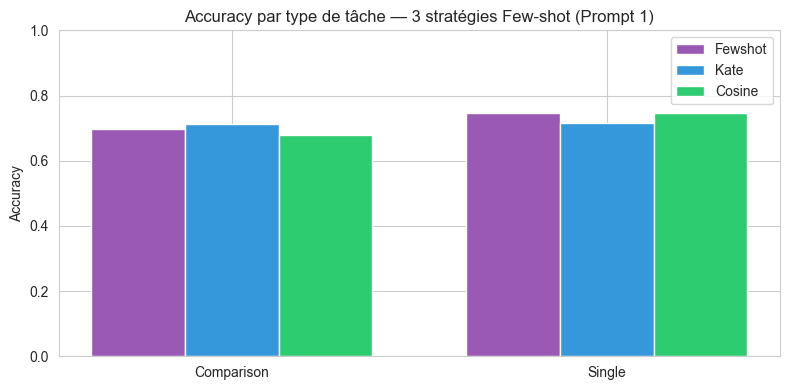

,Fewshot,Kate,Cosine
type,,,
Comparison,0.697417,0.712177,0.678967
Single,0.746725,0.716157,0.746725


In [101]:
acc_cols = [c for c in df_merged.columns if c.startswith('is_correct_')]
strategy_names = [c.replace('is_correct_', '') for c in acc_cols]
colors = ['#9b59b6', '#3498db', '#2ecc71'][:len(strategy_names)]

acc_by_type = df_merged.groupby('type')[acc_cols].mean()
acc_by_type.columns = strategy_names
n_cat = len(acc_by_type.index)
width = 0.25
x = np.arange(n_cat)
fig, ax = plt.subplots(figsize=(8, 4))
for i, name in enumerate(strategy_names):
    offset = (i - len(strategy_names)/2 + 0.5) * width
    ax.bar(x + offset, acc_by_type[name], width, label=name, color=colors[i])
ax.set_xticks(x)
ax.set_xticklabels(acc_by_type.index)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.legend()
ax.set_title('Accuracy par type de tâche — 3 stratégies Few-shot (Prompt 1)')
plt.tight_layout()
fig.savefig(FIGURES_DIR / '02_accuracy_par_type.png', dpi=150, bbox_inches='tight')
plt.show()
display(acc_by_type)


## 5. Analyse par section du protocole


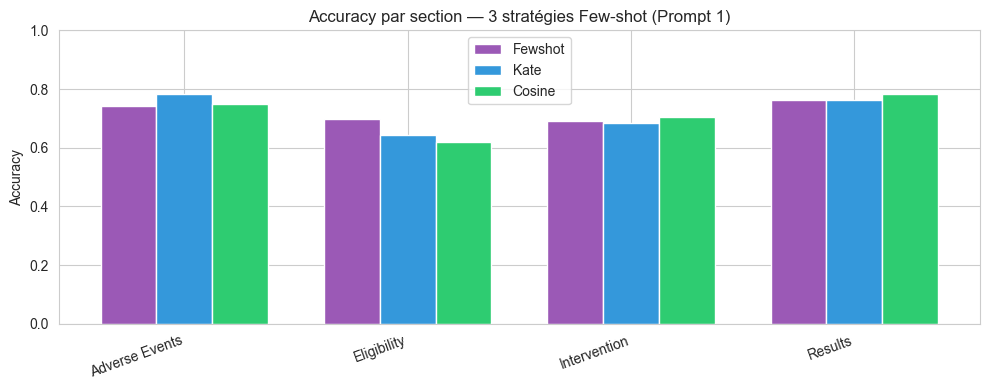

,Fewshot,Kate,Cosine
section_id,,,
Adverse Events,0.741667,0.783333,0.750000
Eligibility,0.696970,0.643939,0.621212
Intervention,0.690141,0.683099,0.704225
Results,0.764151,0.764151,0.783019


In [102]:
acc_by_sec = df_merged.groupby('section_id')[acc_cols].mean()
acc_by_sec.columns = strategy_names
n_cat = len(acc_by_sec.index)
x = np.arange(n_cat)
fig, ax = plt.subplots(figsize=(10, 4))
for i, name in enumerate(strategy_names):
    offset = (i - len(strategy_names)/2 + 0.5) * width
    ax.bar(x + offset, acc_by_sec[name], width, label=name, color=colors[i])
ax.set_xticks(x)
ax.set_xticklabels(acc_by_sec.index, rotation=20, ha='right')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.legend()
ax.set_title('Accuracy par section — 3 stratégies Few-shot (Prompt 1)')
plt.tight_layout()
fig.savefig(FIGURES_DIR / '03_accuracy_par_section.png', dpi=150, bbox_inches='tight')
plt.show()
display(acc_by_sec)


### 5b. Synthèse : performance par type ET par section (un seul graphique)

Un seul graphique pour justifier le choix de stratégie : **2 panneaux** (Single | Comparison), avec les **sections** en abscisse et les **3 modèles** en barres groupées.


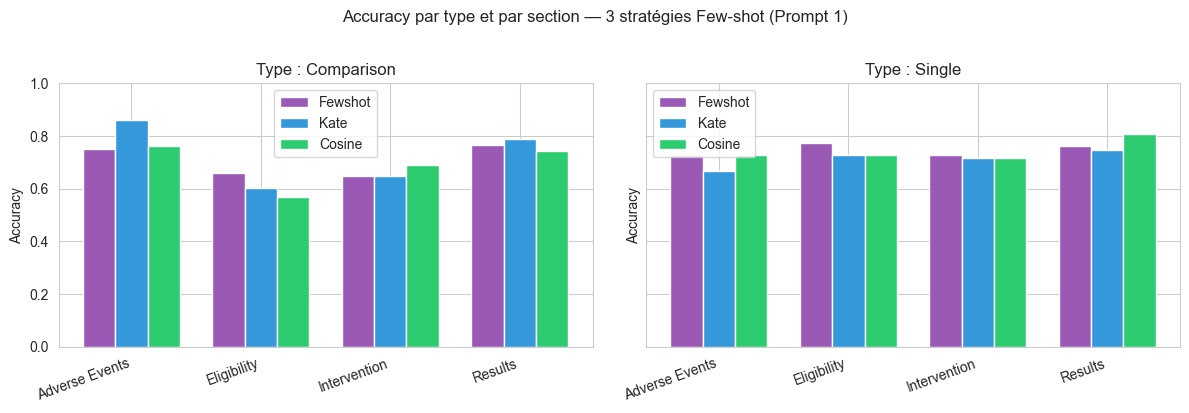

Fewshot      Kate    Cosine
type       section_id                                  
Comparison Adverse Events  0.750000  0.861111  0.763889
           Eligibility     0.659091  0.602273  0.568182
           Intervention    0.647059  0.647059  0.691176
           Results         0.767442  0.790698  0.744186
Single     Adverse Events  0.729167  0.666667  0.729167
           Eligibility     0.772727  0.727273  0.727273
           Intervention    0.729730  0.716216  0.716216
           Results         0.761905  0.746032  0.809524

In [103]:
acc_type_sec = df_merged.groupby(['type', 'section_id'])[acc_cols].mean()
acc_type_sec.columns = strategy_names
types = acc_type_sec.index.get_level_values('type').unique().tolist()
sections = acc_type_sec.index.get_level_values('section_id').unique().tolist()
n_sec = len(sections)
width = 0.25
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for idx, t in enumerate(types):
    ax = axes[idx]
    data = acc_type_sec.xs(t, level='type')
    data = data.reindex(sections)
    x = np.arange(n_sec)
    for i, name in enumerate(strategy_names):
        offset = (i - len(strategy_names)/2 + 0.5) * width
        ax.bar(x + offset, data[name], width, label=name, color=colors[i])
    ax.set_xticks(x)
    ax.set_xticklabels(sections, rotation=20, ha='right')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1)
    ax.legend()
    ax.set_title(f'Type : {t}')
fig.suptitle('Accuracy par type et par section — 3 stratégies Few-shot (Prompt 1)', fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / '02b_accuracy_type_et_section.png', dpi=150, bbox_inches='tight')
plt.show()
display(acc_type_sec)


## 6. Analyse par longueur du prompt (court / moyen / long)

On regarde si les modèles se trompent davantage sur les **prompts longs** (prémisse + hypothèse plus longues) ou **courts**.


/var/folders/71/b1s1b9y50596_3t1fgw_1dzw0000gn/T/ipykernel_18390/2979458848.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  acc_by_len = df_merged.groupby('length_bin')[acc_cols].mean()


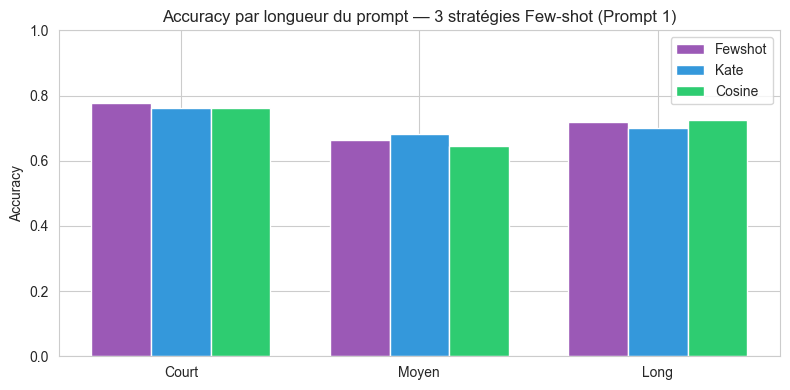

,Fewshot,Kate,Cosine
length_bin,,,
Court,0.778443,0.760479,0.760479
Moyen,0.662651,0.680723,0.644578
Long,0.718563,0.700599,0.724551


Effectifs par bin:
length_bin
Court    167
Moyen    166
Long     167
dtype: int64


/var/folders/71/b1s1b9y50596_3t1fgw_1dzw0000gn/T/ipykernel_18390/2979458848.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_merged.groupby('length_bin').size())


In [104]:
acc_by_len = df_merged.groupby('length_bin')[acc_cols].mean()
acc_by_len.columns = strategy_names
n_cat = len(acc_by_len.index)
x = np.arange(n_cat)
fig, ax = plt.subplots(figsize=(8, 4))
for i, name in enumerate(strategy_names):
    offset = (i - len(strategy_names)/2 + 0.5) * width
    ax.bar(x + offset, acc_by_len[name], width, label=name, color=colors[i])
ax.set_xticks(x)
ax.set_xticklabels(acc_by_len.index)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.legend()
ax.set_title('Accuracy par longueur du prompt — 3 stratégies Few-shot (Prompt 1)')
plt.tight_layout()
fig.savefig(FIGURES_DIR / '04_accuracy_par_longueur.png', dpi=150, bbox_inches='tight')
plt.show()
display(acc_by_len)
print("Effectifs par bin:")
print(df_merged.groupby('length_bin').size())


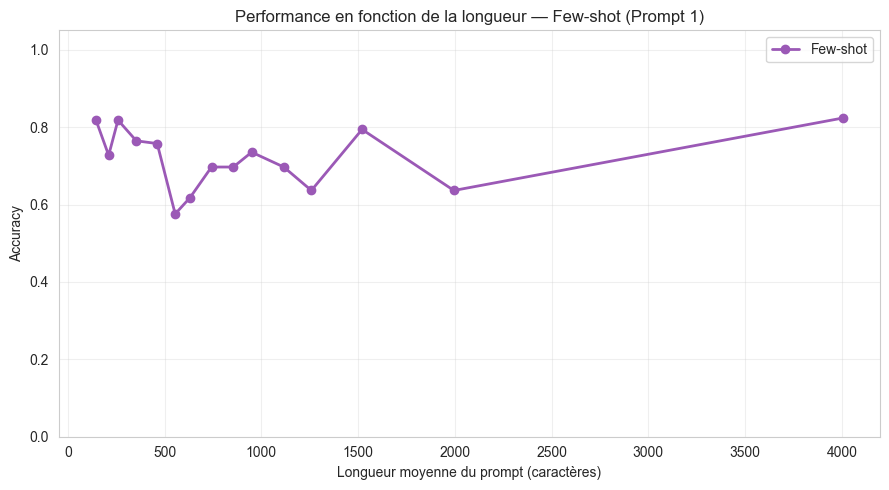

In [105]:
# Courbe : performance (accuracy) en fonction de la longueur du prompt
# Bins par *rang* de longueur (percentile) pour avoir toujours N_BINS points, même si les longueurs varient peu
N_BINS = 15
for df in [df_merged]:
    df['len_bin_idx'] = (df['prompt_len'].rank(pct=True, method='first') * N_BINS).astype(int).clip(0, N_BINS - 1)

def accuracy_vs_length(df):
    g = df.groupby('len_bin_idx').agg(len_moy=('prompt_len', 'mean'), n=('prompt_len', 'count'), correct=('is_correct', 'sum'))
    g = g[g['n'] >= 1]
    g['accuracy'] = g['correct'] / g['n']
    return g.sort_index()

curve = accuracy_vs_length(df_merged)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(curve['len_moy'], curve['accuracy'], 'o-', color='#9b59b6', label='Few-shot', linewidth=2, markersize=6)
ax.set_xlabel('Longueur moyenne du prompt (caractères)')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.05)
ax.legend()
ax.set_title('Performance en fonction de la longueur — Few-shot (Prompt 1)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(FIGURES_DIR / '04b_accuracy_vs_longueur_courbe.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Quand le modèle se trompe

Distribution des **erreurs** : par type, section, longueur ; et type d'erreur (Entailment prédit Contradiction ou l'inverse).


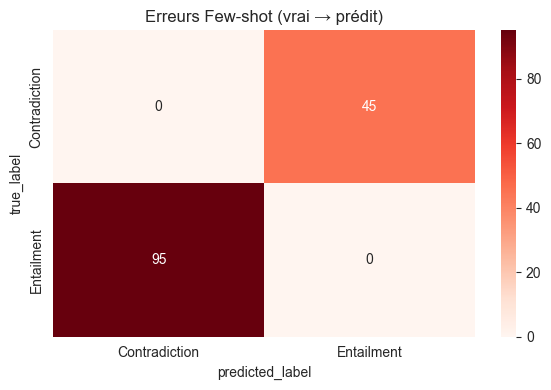

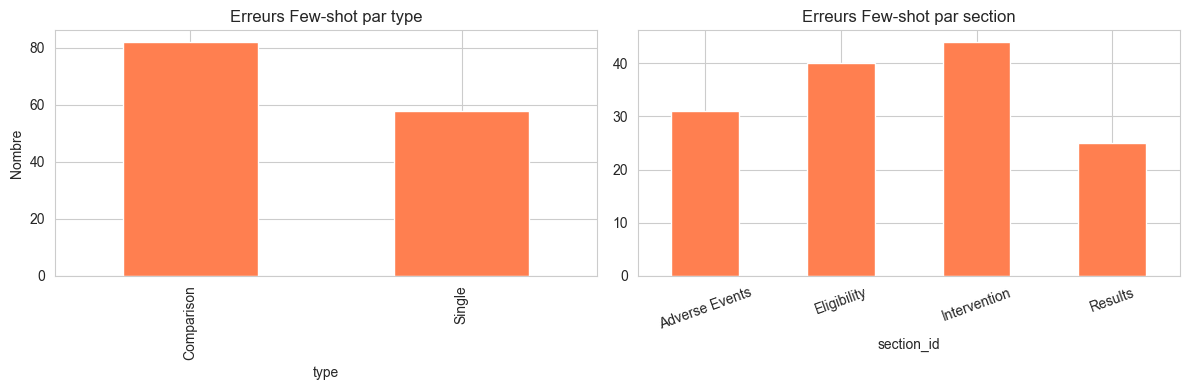

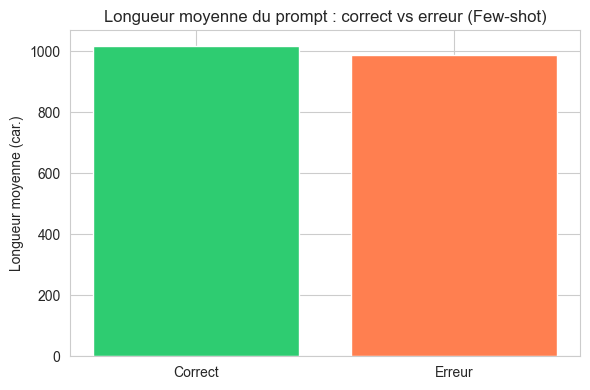

In [106]:
err = df_merged[~df_merged['is_correct']]
fig, ax = plt.subplots(figsize=(6, 4))
if len(err) > 0:
    c = err.groupby('true_label')['predicted_label'].value_counts().unstack(fill_value=0)
    sns.heatmap(c, annot=True, fmt='d', cmap='Reds', ax=ax)
ax.set_title('Erreurs Few-shot (vrai → prédit)')
plt.tight_layout()
fig.savefig(FIGURES_DIR / '05_erreurs_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if len(err) > 0:
    err.groupby('type').size().plot(kind='bar', ax=axes[0], color='coral')
    axes[0].set_title('Erreurs Few-shot par type')
    axes[0].set_ylabel('Nombre')
    err.groupby('section_id').size().plot(kind='bar', ax=axes[1], color='coral')
    axes[1].set_title('Erreurs Few-shot par section')
    axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
fig.savefig(FIGURES_DIR / '06_erreurs_par_type_et_section.png', dpi=150, bbox_inches='tight')
plt.show()

correct_len = df_merged[df_merged['is_correct']]['prompt_len'].mean()
wrong_len = df_merged[~df_merged['is_correct']]['prompt_len'].mean()
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Correct', 'Erreur'], [correct_len, wrong_len], color=['#2ecc71', 'coral'])
ax.set_ylabel('Longueur moyenne (car.)')
ax.set_title('Longueur moyenne du prompt : correct vs erreur (Few-shot)')
plt.tight_layout()
fig.savefig(FIGURES_DIR / '07_longueur_erreurs_vs_corrects.png', dpi=150, bbox_inches='tight')
plt.show()


### 7b. Cas où le modèle n'a pas produit un label reconnu (UNKNOWN)

Quand le script d'évaluation ne trouve ni "Entailment" ni "Contradiction" dans les 50 premiers caractères de la sortie, le label est marqué **UNKNOWN**. Ci-dessous : les exemples concernés avec la sortie brute du modèle pour analyser le problème.

In [107]:
unknown = df_merged[df_merged['predicted_label'] == 'UNKNOWN']
print(f"Few-shot : {len(unknown)} cas UNKNOWN")
if len(unknown) > 0:
    cols = ['index', 'true_label', 'type', 'section_id']
    if 'raw_generated' in unknown.columns:
        cols.append('raw_generated')
    display_df = unknown[cols].copy()
    if 'raw_generated' in unknown.columns:
        display_df['raw_generated'] = display_df['raw_generated'].str[:200] + ('...' if display_df['raw_generated'].str.len().gt(200).any() else '')
    display(display_df)
    unknown[['index', 'true_label', 'type', 'section_id', 'premise', 'hypothesis']].assign(raw=unknown['raw_generated']).to_csv(FIGURES_DIR / 'cas_unknown.csv', index=False)
    print(f"\n>>> Cas UNKNOWN exportés : {FIGURES_DIR / 'cas_unknown.csv'}")
else:
    print("Aucun cas UNKNOWN.")

Few-shot : 0 cas UNKNOWN
Aucun cas UNKNOWN.


## 8. Répartition correct / erreur

Nombre d'exemples corrects vs en erreur pour le modèle few-shot.


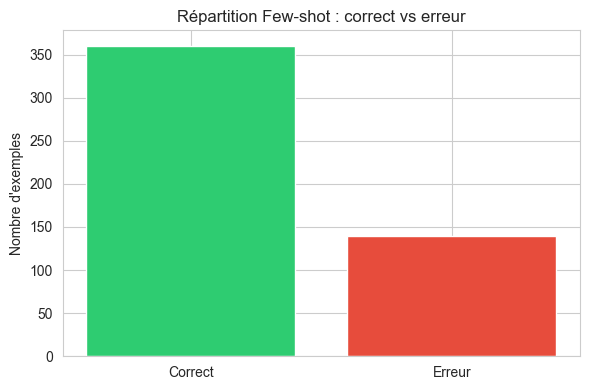

Sections (accuracy décroissante) :
                  n  correct  accuracy
section_id                            
Results         106       81  0.764151
Adverse Events  120       89  0.741667
Eligibility     132       92  0.696970
Intervention    142       98  0.690141


In [108]:
n_correct = df_merged['is_correct'].sum()
n_wrong = (~df_merged['is_correct']).sum()
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Correct', 'Erreur'], [n_correct, n_wrong], color=['#2ecc71', '#e74c3c'])
ax.set_ylabel('Nombre d\'exemples')
ax.set_title('Répartition Few-shot : correct vs erreur')
plt.tight_layout()
fig.savefig(FIGURES_DIR / '08_correct_vs_erreur.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sections (accuracy décroissante) :')
print(acc_sec.sort_values('accuracy', ascending=False)[['n', 'correct', 'accuracy']])


## 9. Régressions / Améliorations

N/A : un seul modèle (few-shot), pas de comparaison baseline vs finetuné.


In [109]:
# Un seul modèle (few-shot) : pas de régressions/améliorations à calculer
print("N/A — un seul modèle (few-shot).")


N/A — un seul modèle (few-shot).


## 10. Améliorations

N/A (un seul modèle).


In [110]:
print("N/A — un seul modèle (few-shot).")


N/A — un seul modèle (few-shot).


## 11. Exemples d'erreurs

Quelques exemples où le modèle few-shot s'est trompé.


In [111]:
N_EX = 5
err_ex = df_merged[~df_merged['is_correct']]
print(f'Exemples d\'erreurs (Few-shot s\'est trompé) — {min(N_EX, len(err_ex))} premiers :')
for _, row in err_ex.head(N_EX).iterrows():
    print(f"  Index {row['index']} | Type: {row['type']} | Section: {row['section_id']} | Vrai: {row['true_label']} | Prédit: {row['predicted_label']}")
    print(f"    Statement: {str(row.get('statement', row.get('hypothesis', '')))[:120]}...")


Exemples d'erreurs (Few-shot s'est trompé) — 5 premiers :
  Index 2 | Type: Comparison | Section: Eligibility | Vrai: Entailment | Prédit: Contradiction
    Statement: the secondary trial requires patients to be over a certain age, but the primary trial does not specify an age range for ...
  Index 5 | Type: Comparison | Section: Adverse Events | Vrai: Entailment | Prédit: Contradiction
    Statement: There are no cases of anorexia, hypothermia or hallucinations recorded in the Aes of the primary trial or the secondary ...
  Index 7 | Type: Comparison | Section: Eligibility | Vrai: Contradiction | Prédit: Entailment
    Statement: Any patients with Documented allergy to cephalosporin or trimethoprim/sulfamethoxazole will not be eligible for the seco...
  Index 13 | Type: Single | Section: Intervention | Vrai: Contradiction | Prédit: Entailment
    Statement: Cohort A and B of the primary trial are administered the same Three electroporation injections of LD V934...
  Index 35 | Type: S

## 12. Synthèse pour le rapport

Résumé rédigé : **dans quels cas le modèle se trompe** et **dans quels cas il est très bon**. Le fichier est sauvegardé dans le dossier figures pour inclusion au rapport.

In [112]:
# Synthèse : quand le modèle few-shot se trompe vs quand il est très bon
err_syn = df_merged[~df_merged['is_correct']]
correct_syn = df_merged[df_merged['is_correct']]

lines = [
    f"# Synthèse analyse d'erreurs — Few-shot (Prompt 1)",
    "",
    "## Dans quels cas le modèle se trompe le plus",
    f"- Sections les plus difficiles : {err_syn.groupby('section_id').size().sort_values(ascending=False).head(3).to_dict()}",
    f"- Types les plus difficiles : {err_syn.groupby('type').size().sort_values(ascending=False).to_dict()}",
    f"- Longueur moyenne du prompt (car.) pour les erreurs : {err_syn['prompt_len'].mean():.0f}",
    f"- Longueur moyenne pour les corrects : {correct_syn['prompt_len'].mean():.0f}",
    "",
    "## Dans quels cas le modèle est très bon",
    f"- Sections avec la meilleure accuracy : {acc_sec.nlargest(3, 'accuracy')['accuracy'].to_dict()}",
    f"- Types avec la meilleure accuracy : {acc_type['accuracy'].to_dict()}",
    f"- Bins de longueur : {acc_len['accuracy'].to_dict()}",
    f"- Nombre de prédictions correctes : {df_merged['is_correct'].sum()}",
]
synthese_path = FIGURES_DIR / "synthese_erreurs_fewshot.txt"
synthese_path.write_text("\n".join(lines), encoding="utf-8")
print("\n".join(lines))
print(f"\n>>> Synthèse sauvegardée : {synthese_path}")

# Synthèse analyse d'erreurs — Few-shot (Prompt 1)

## Dans quels cas le modèle se trompe le plus
- Sections les plus difficiles : {'Intervention': 44, 'Eligibility': 40, 'Adverse Events': 31}
- Types les plus difficiles : {'Comparison': 82, 'Single': 58}
- Longueur moyenne du prompt (car.) pour les erreurs : 988
- Longueur moyenne pour les corrects : 1017

## Dans quels cas le modèle est très bon
- Sections avec la meilleure accuracy : {'Results': 0.7641509433962265, 'Adverse Events': 0.7416666666666667, 'Eligibility': 0.696969696969697}
- Types avec la meilleure accuracy : {'Comparison': 0.6974169741697417, 'Single': 0.7467248908296943}
- Bins de longueur : {'Court': 0.7784431137724551, 'Moyen': 0.6626506024096386, 'Long': 0.718562874251497}
- Nombre de prédictions correctes : 360

>>> Synthèse sauvegardée : /Users/lubin/Documents/NLI_Finetuning/NLI4CT/results/Fewshot/figures/synthese_erreurs_fewshot.txt


## 13. Export des résultats détaillés


In [113]:
df_export = df_merged[['index', 'premise', 'hypothesis', 'true_label', 'predicted_label', 'is_correct', 'premise_len', 'hypothesis_len', 'prompt_len', 'length_bin', 'type', 'section_id']].copy()
out_csv = RESULTS_DIR / 'error_analysis_detailed_fewshot_prompt1.csv'
df_export.to_csv(out_csv, index=False)
print(f'Résultats détaillés sauvegardés : {out_csv}')
print(f'Figures sauvegardées dans : {FIGURES_DIR}')


Résultats détaillés sauvegardés : /Users/lubin/Documents/NLI_Finetuning/NLI4CT/results/Fewshot/error_analysis_detailed_fewshot_prompt1.csv
Figures sauvegardées dans : /Users/lubin/Documents/NLI_Finetuning/NLI4CT/results/Fewshot/figures
